In [1]:
"# Dự đoán và Xây dựng Danh Mục Đầu Tư với LSTM, LR, và SVR\n",
"Trong notebook này, chúng ta sẽ thực hiện các bước sau:\n",
"1. Tải dữ liệu chứng khoán từ Vnstock.\n",
"2. Dự đoán giá cổ phiếu bằng các mô hình LSTM, Linear Regression (LR) và Support Vector Regression (SVR).\n",
"3. Xây dựng danh mục đầu tư dựa trên dự đoán.\n",
"4. Tối ưu hóa danh mục bằng Monte Carlo Simulation (MCS) và Mean-Variance Optimization (MVO).\n",
"5. Vẽ đồ thị để so sánh hiệu suất.\n"

'5. Vẽ đồ thị để so sánh hiệu suất.\n'

In [1]:
# -------------------- Import các thư viện cần thiết --------------------
from vnstock import *
import pandas as pd
import numpy as np
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy.optimize import minimize
from scipy.stats import skew, kurtosis
import matplotlib.pyplot as plt
import joblib
import seaborn as sns
from IPython.display import display

Phiên bản Vnstock 3.2.2 đã có mặt, vui lòng cập nhật với câu lệnh : `pip install vnstock --upgrade`.
Lịch sử phiên bản: https://vnstocks.com/docs/tai-lieu/lich-su-phien-ban
Phiên bản hiện tại 3.1.0.2

In [2]:
# -------------------- Khởi tạo đối tượng Vnstock và lấy danh sách mã VN100 --------------------
stock = Vnstock().stock(source='VCI')
Vn100_list = stock.listing.symbols_by_group('VN100')

2025-03-26 22:39:24 - vnstock.common.vnstock - INFO - Mã chứng khoán không được chỉ định, chương trình mặc định sử dụng VN30F1M
2025-03-26 22:39:24 - vnstock.common.data.data_explorer - INFO - Mã chứng khoán không được chỉ định, chương trình mặc định sử dụng VN30F1M
2025-03-26 22:39:24 - vnstock.common.data.data_explorer - WARNING - Thông tin niêm yết & giao dịch sẽ được truy xuất từ TCBS


# Dùng để chuẩn bị csv - test không dùng


In [3]:
# -------------------- Hàm lấy dữ liệu từ Vnstock --------------------
def get_data(start, end):
    data = []
    for sym in Vn100_list:
        try:
            temp = stock.quote.history(
                symbol=sym,
                start=start,
                end=end,
                interval='1D'
            )
            temp = pd.DataFrame(temp)
            temp['stock_id'] = sym
            data.append(temp)
        except Exception as e:
            print(f'Không thể lấy dữ liệu cho mã {sym}: {e}')
    vnindex = pd.DataFrame(stock.quote.history(
        symbol='VNINDEX',
        start=start,
        end=end,
        interval='1D'
    ))
    vnindex['stock_id'] = 'VNINDEX'
    data.append(vnindex)
    data = pd.concat(data, ignore_index=False)
    return data
# Lấy dữ liệu từ ngày 1/9/2024 đến 15/3/2025
stock_data = get_data('2024-09-01', '2025-03-15')
stock_data.to_csv('stock_data.csv', index=False)  # Lưu dữ liệu 15/3/2025 để tính ngày cuối

In [4]:
def get_data(start, end):
    data = []
    for sym in Vn100_list:
        try:
            temp = stock.quote.history(
                symbol=sym,
                start=start,
                end=end,
                interval='1D'
            )
            temp = pd.DataFrame(temp)
            temp['stock_id'] = sym
            data.append(temp)
        except Exception as e:
            print(f'Không thể lấy dữ liệu cho mã {sym}: {e}')
    vnindex = pd.DataFrame(stock.quote.history(
        symbol='VNINDEX',
        start=start,
        end=end,
        interval='1D'
    ))
    vnindex['stock_id'] = 'VNINDEX'
    data.append(vnindex)
    data = pd.concat(data, ignore_index=False)
    return data
# Lấy dữ liệu từ ngày 1/9/2024 đến 13/3/2025
stock_data = get_data('2024-09-01', '2025-03-13')
stock_data.to_csv('stock_data_prev.csv', index=False) # Lưu dữ liệu 13/3/2025 để tính ngày kế cuối

# Đọc dữ liệu từ csv

In [5]:
# -------------------- Hàm đọc dữ liệu từ CSV --------------------
def read_data(file_path, vn100_list):
    stock_df = pd.read_csv(file_path)
    stock_df['time'] = pd.to_datetime(stock_df['time'])
    temp = stock_df.groupby('stock_id')
    date_list = temp.get_group(vn100_list[0])['time'].tolist()
    stock_dict = {}
    for stock, stock_data in temp:
        if stock_data.shape[0] == len(date_list):
            stock_dict[stock] = stock_data.drop(columns=['stock_id', 'time'])
        else:
            print(f'Dữ liệu của mã {stock} không đồng nhất với các mã chứng khoán khác')
            return None, None
    return stock_dict, date_list

stocks_dict, date_list = read_data('stock_data_prev.csv', Vn100_list)
temp_dict = stocks_dict 

In [6]:
print(stocks_dict.keys())
print(f"Ngày bắt đầu: {date_list[0]}")
print(f"Ngày kết thúc: {date_list[-1]}")
print(f"Số lượng ngày: {len(date_list)}")

dict_keys(['AAA', 'ACB', 'ANV', 'BCG', 'BCM', 'BID', 'BMP', 'BSI', 'BVH', 'BWE', 'CII', 'CMG', 'CTD', 'CTG', 'CTR', 'CTS', 'DBC', 'DCM', 'DGC', 'DGW', 'DIG', 'DPM', 'DSE', 'DXG', 'DXS', 'EIB', 'EVF', 'FPT', 'FRT', 'FTS', 'GAS', 'GEX', 'GMD', 'GVR', 'HAG', 'HCM', 'HDB', 'HDC', 'HDG', 'HHV', 'HPG', 'HSG', 'HT1', 'IMP', 'KBC', 'KDC', 'KDH', 'KOS', 'LPB', 'MBB', 'MSB', 'MSN', 'MWG', 'NAB', 'NKG', 'NLG', 'NT2', 'OCB', 'PAN', 'PC1', 'PDR', 'PHR', 'PLX', 'PNJ', 'POW', 'PPC', 'PTB', 'PVD', 'PVT', 'REE', 'SAB', 'SBT', 'SCS', 'SHB', 'SIP', 'SJS', 'SSB', 'SSI', 'STB', 'SZC', 'TCB', 'TCH', 'TLG', 'TPB', 'VCB', 'VCG', 'VCI', 'VGC', 'VHC', 'VHM', 'VIB', 'VIC', 'VIX', 'VJC', 'VND', 'VNINDEX', 'VNM', 'VPB', 'VPI', 'VRE', 'VTP'])
Ngày bắt đầu: 2024-09-04 00:00:00
Ngày kết thúc: 2025-03-13 00:00:00
Số lượng ngày: 131


# Kiểm tra dữ liệu

### Table cho price

In [7]:
df = pd.read_csv('stock_data.csv')
print(df.head())

         time   open   high    low  close   volume stock_id
0  2024-09-04  10.05  10.15   9.97  10.10  3333000      AAA
1  2024-09-05  10.10  10.35  10.10  10.10  3063500      AAA
2  2024-09-06  10.10  10.15   9.85   9.90  7338600      AAA
3  2024-09-09   9.70   9.89   9.70   9.80  3423700      AAA
4  2024-09-10   9.80   9.85   9.71   9.72  2438300      AAA


In [8]:
results_price = []
for stock, group in df.groupby('stock_id'):
    close_prices = group['close']
    mean_price = np.mean(close_prices)
    min_price = np.min(close_prices)
    max_price = np.max(close_prices)
    variance = np.var(close_prices)
    std_price = np.std(close_prices)
    skewness = skew(close_prices)
    kurt = kurtosis(close_prices)

    results_price.append([stock, mean_price, min_price, max_price, variance, std_price, skewness, kurt])

stats_df = pd.DataFrame(results_price, columns=['Stocks', 'mean', 'min', 'max', 'variance', 'std', 'skewness', 'kurtosis'])
stats_df.to_csv('stats_price.csv', index=False)

In [9]:
results_price = None
stats_df = None

### Tính return và vẽ biểu đồ

In [10]:
df = pd.read_csv("stock_data.csv", parse_dates=["time"])  # Chuyển cột time thành dạng datetime

# Chỉ lấy cột "time", "stock_id", "close"
df = df[["time", "stock_id", "close"]]

# Tính daily return
df["daily_return"] = df.groupby("stock_id")["close"].pct_change()

df["year"] = df["time"].dt.year

df = df.dropna(subset=["daily_return"])  # Xóa NaN
df = df[df["daily_return"] != 0]  # Xóa giá trị daily_return = 0

In [11]:
df.head()

,time,stock_id,close,daily_return,year
2,2024-09-06,AAA,9.90,-0.019802,2024
3,2024-09-09,AAA,9.80,-0.010101,2024
4,2024-09-10,AAA,9.72,-0.008163,2024
5,2024-09-11,AAA,9.60,-0.012346,2024
6,2024-09-12,AAA,9.68,0.008333,2024


In [12]:
returns_summary = df.groupby("stock_id")["daily_return"].agg(["mean", "min", "max", "var", "std", "skew", kurtosis])

# Định dạng bảng
returns_summary.columns = ["Mean", "Min", "Max", "Variance", "Std Dev", "Skewness", "Kurtosis"]

# Hiển thị 10 dòng đầu tiên
print(returns_summary.head(10))

              Mean       Min       Max  Variance   Std Dev  Skewness  Kurtosis
stock_id                                                                      
AAA      -0.001264 -0.045455  0.056423  0.000168  0.012968  0.718851  3.163780
ACB       0.000493 -0.019685  0.034274  0.000083  0.009122  0.797434  1.592688
ANV       0.001025 -0.060109  0.068871  0.000314  0.017716 -0.032154  2.198165
BCG      -0.004057 -0.069444  0.051805  0.000404  0.020093 -0.824739  2.025437
BCM       0.001041 -0.044776  0.069333  0.000209  0.014441  1.098796  4.341687
BID       0.000042 -0.022989  0.041237  0.000107  0.010340  0.399437  1.075085
BMP       0.001653 -0.038149  0.069600  0.000442  0.021033  0.876793  1.067153
BSI       0.001072 -0.068134  0.069686  0.000368  0.019188  0.480707  2.500541
BVH       0.001921 -0.033981  0.069820  0.000286  0.016920  1.433978  4.205280
BWE       0.000260 -0.024446  0.067886  0.000168  0.012973  1.762820  6.281788


In [13]:
returns_summary.to_csv('returns_summary.csv', index=False)

# Hàm chuẩn bị dữ liệu và huấn luyện mô hình

In [14]:
# -------------------- Hàm dự đoán với các mô hình --------------------
def take_x_dates(stock_id, x_dates):
    return stocks_dict[stock_id][-x_dates-1:-1]

def predict_x_dates(model, input_data):
    scaler = MinMaxScaler()
    temp = scaler.fit_transform(input_data)
    if isinstance(model, Sequential):
        prediction = model.predict(np.expand_dims(temp, axis=0))
        prediction_reshaped = np.zeros((prediction.shape[0], 5))
        prediction_reshaped[:, 3] = prediction[:, 0].flatten()
        prediction = scaler.inverse_transform(prediction_reshaped)[:, 3]
    else:
        prediction = model.predict(temp.flatten().reshape(1, -1))
        prediction_reshaped = np.zeros((prediction.shape[0], 5))
        prediction_reshaped[:, 3] = prediction
        prediction = scaler.inverse_transform(prediction_reshaped)[:, 3]
    return prediction

def predict_x_dates_all_stocks(model, x_dates):
    return np.array([predict_x_dates(model, take_x_dates(stock_id, x_dates)) for stock_id in Vn100_list]).reshape(1, -1)

def predict_with_all_models(models, x_dates=[10, 20, 30, 40, 50, 60, 70, 80, 90, 100]):
    predictions = np.empty((0, 100))
    for j, model_group in enumerate(models):  # Duyệt qua từng nhóm mô hình (LSTM, LR, SVR)
        for i, model in enumerate(model_group):
            period = x_dates[i]
            if j <= 9:
                pred = predict_x_dates_all_stocks(model, period) - 0.2
            else:
                pred = predict_x_dates_all_stocks(model, period)
            predictions = np.concatenate((predictions, pred), axis=0)
    return predictions

In [15]:
# -------------------- Dự đoán với LSTM, LR, SVR --------------------
x_dates = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
model_1 = load_model('MODELS/model_1_1.keras')
model_2 = load_model('MODELS/model_2_3.keras')
model_3 = load_model('MODELS/model_3_3.keras')
model_4 = load_model('MODELS/model_4_2.keras')
model_5 = load_model('MODELS/model_5_1.keras')
model_6 = load_model('MODELS/model_6_2.keras')
model_7 = load_model('MODELS/model_7_2.keras')
model_8 = load_model('MODELS/model_8_2.keras')
model_9 = load_model('MODELS/model_9_3.keras')
model_10 = load_model('MODELS/model_10_2.keras')

model_11 = joblib.load("MODELS/lr_model.pkl_10")
model_12 = joblib.load("MODELS/lr_model.pkl_20")
model_13 = joblib.load("MODELS/lr_model.pkl_30")
model_14 = joblib.load("MODELS/lr_model.pkl_40")
model_15 = joblib.load("MODELS/lr_model.pkl_50")
model_16 = joblib.load("MODELS/lr_model.pkl_60")
model_17 = joblib.load("MODELS/lr_model.pkl_70")
model_18 = joblib.load("MODELS/lr_model.pkl_80")
model_19 = joblib.load("MODELS/lr_model.pkl_90")
model_20 = joblib.load("MODELS/lr_model.pkl_100")

model_21 = joblib.load("MODELS/svr_model.pkl_10")
model_22 = joblib.load("MODELS/svr_model.pkl_20")
model_23 = joblib.load("MODELS/svr_model.pkl_30")
model_24 = joblib.load("MODELS/svr_model.pkl_40")    
model_25 = joblib.load("MODELS/svr_model.pkl_50")
model_26 = joblib.load("MODELS/svr_model.pkl_60")
model_27 = joblib.load("MODELS/svr_model.pkl_70")
model_28 = joblib.load("MODELS/svr_model.pkl_80")
model_29 = joblib.load("MODELS/svr_model.pkl_90")
model_30 = joblib.load("MODELS/svr_model.pkl_100")

model_group_1 = [model_1, model_2, model_3, model_4, model_5, model_6, model_7, model_8, model_9, model_10]
model_group_2 = [model_11, model_12, model_13, model_14, model_15, model_16, model_17, model_18, model_19, model_20]
model_group_3 = [model_21, model_22, model_23, model_24, model_25, model_26, model_27, model_28, model_29, model_30]

models = [model_group_1, model_group_2, model_group_3]

Trying to unpickle estimator LinearRegression from version 1.6.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
Trying to unpickle estimator SVR from version 1.6.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations


In [16]:
# Dự đoán ngày 13/3/2025, dùng để tính pred_price ngày trước
predictions_prev = predict_with_all_models(models, x_dates=x_dates)
predictions_prev = np.round(predictions_prev, 2)
predictions_prev.shape

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 689ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━

(30, 100)

In [8]:
predictions_prev

array([[  8.58,  26.06,  17.16, ...,  58.29,  17.56, 153.43],
       [  8.6 ,  26.09,  17.2 , ...,  58.17,  17.57, 153.58],
       [  8.55,  25.9 ,  17.03, ...,  57.94,  17.3 , 153.23],
       ...,
       [  8.01,  24.24,  16.48, ...,  56.32,  16.03, 116.32],
       [  8.01,  24.24,  16.48, ...,  56.32,  16.03,  93.31],
       [  8.03,  24.24,  16.36, ...,  56.32,  16.08,  90.45]])

In [ ]:
# Dự đoán ngày 14/3/2025, dùng để tính pred_price ngày cuối
stocks_dict, date_list = read_data('stock_data.csv', Vn100_list)
print(stocks_dict.keys())
print(f"Ngày bắt đầu: {date_list[0]}")
print(f"Ngày kết thúc: {date_list[-1]}")
print(f"Số lượng ngày: {len(date_list)}")
predictions = predict_with_all_models(models, x_dates=x_dates)
predictions = np.round(predictions, 2)
predictions.shape

dict_keys(['AAA', 'ACB', 'ANV', 'BCG', 'BCM', 'BID', 'BMP', 'BSI', 'BVH', 'BWE', 'CII', 'CMG', 'CTD', 'CTG', 'CTR', 'CTS', 'DBC', 'DCM', 'DGC', 'DGW', 'DIG', 'DPM', 'DSE', 'DXG', 'DXS', 'EIB', 'EVF', 'FPT', 'FRT', 'FTS', 'GAS', 'GEX', 'GMD', 'GVR', 'HAG', 'HCM', 'HDB', 'HDC', 'HDG', 'HHV', 'HPG', 'HSG', 'HT1', 'IMP', 'KBC', 'KDC', 'KDH', 'KOS', 'LPB', 'MBB', 'MSB', 'MSN', 'MWG', 'NAB', 'NKG', 'NLG', 'NT2', 'OCB', 'PAN', 'PC1', 'PDR', 'PHR', 'PLX', 'PNJ', 'POW', 'PPC', 'PTB', 'PVD', 'PVT', 'REE', 'SAB', 'SBT', 'SCS', 'SHB', 'SIP', 'SJS', 'SSB', 'SSI', 'STB', 'SZC', 'TCB', 'TCH', 'TLG', 'TPB', 'VCB', 'VCG', 'VCI', 'VGC', 'VHC', 'VHM', 'VIB', 'VIC', 'VIX', 'VJC', 'VND', 'VNINDEX', 'VNM', 'VPB', 'VPI', 'VRE', 'VTP'])
Ngày bắt đầu: 2024-09-04 00:00:00
Ngày kết thúc: 2025-03-14 00:00:00
Số lượng ngày: 132
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step

(30, 100)

In [10]:
predictions

array([[  8.56,  26.1 ,  17.16, ...,  57.98,  17.76, 154.57],
       [  8.58,  26.09,  17.14, ...,  57.86,  17.8 , 153.82],
       [  8.54,  25.92,  16.96, ...,  57.69,  17.49, 153.41],
       ...,
       [  8.01,  24.24,  16.48, ...,  56.13,  16.06, 116.32],
       [  8.01,  24.24,  16.48, ...,  56.13,  16.06,  93.31],
       [  8.03,  24.24,  16.36, ...,  56.13,  16.08,  90.45]])

In [10]:
# Tính pred_return
pred_return = (predictions - predictions_prev) / predictions_prev

In [11]:
# Tính actual_return = (actual_price - prev_price) / prev_price
actual_values = np.array([stocks_dict[stock].iloc[-1]['close'] for stock in Vn100_list])
actual_returns = (actual_values - np.array([stocks_dict[i].iloc[-2]['close'] for i in Vn100_list])) / np.array([stocks_dict[i].iloc[-2]['close'] for i in Vn100_list]) 

In [12]:
# Gán lại predictions cho từng loại mô hình
predictions_lstm = predictions[:10]  # 10 hàng đầu tiên cho LSTM
predictions_lr = predictions[10:20]  # 10 hàng tiếp theo cho LR
predictions_svr = predictions[20:]   # 10 hàng cuối cho SVR

In [13]:
pred_return_lstm = pred_return[:10]
pred_return_lr = pred_return[10:20]
pred_return_svr = pred_return[20:]

In [44]:
mae_list = []
mse_list = []

In [45]:
for pred in predictions:
    mae = mean_absolute_error(actual_values, pred)
    mse = mean_squared_error(actual_values, pred)
    mae_list.append(mae)
    mse_list.append(mse)

mae_list = np.round(np.array(mae_list), 2)
mse_list = np.round(np.array(mse_list), 2)

In [48]:
mae_df = None

In [53]:
mae_df = pd.DataFrame(
    {
        "Models" : ["LSTM", "LR", "SVR"],
        "MAE" : [np.round(np.mean(mae_list[:10]), 2), np.round(np.mean(mae_list[10:20]), 2), np.round(np.mean(mae_list[20:]), 2)],
        "MSE" : [np.round(np.mean(mse_list[:10]), 2), np.round(np.mean(mse_list[10:20]), 2), np.round(np.mean(mse_list[20:]), 2)]
    }
)

mae_df


,Models,MAE,MSE
0,LSTM,1.28,4.77
1,LR,1.36,6.06
2,SVR,3.44,35.59


# Các hàm xây dựng danh mục đầu tư

In [20]:
# -------------------- Xây dựng danh mục đầu tư --------------------
def calculate_expected_return(predictions, previous):
    return (predictions - previous) / previous

def select_top_stocks(returns, num_stocks=4):
    top_indices = np.argsort(returns, axis=1)[:, -num_stocks:]
    return top_indices

def covariance_matrix(ids, num_data):
    closing_prices = [stocks_dict[id][-(num_data+2):-1]['close'].values for id in ids]
    closing_prices = np.array(closing_prices).T
    daily_returns = (closing_prices[1:] - closing_prices[:-1]) / closing_prices[:-1]
    df_returns = pd.DataFrame(daily_returns, columns=ids)
    cov_matrix = df_returns.cov()

    return cov_matrix

def portfolio_performance(pred_return, weights_list):
    sharpe_ratios = []
    returns = []

    Rf_annual = 0.0297
    Rf_daily = (1 + Rf_annual) ** (1/252) - 1
    for i, pred in enumerate(pred_return):
        expected_returns = pred
        top_indices = select_top_stocks(expected_returns.reshape(1, -1), num_stocks=4)[0]
        top_returns = expected_returns[top_indices]
        weights = weights_list[i] if isinstance(weights_list, list) else weights_list
        portfolio_return = np.dot(top_returns, weights)
        top_ids = [Vn100_list[j] for j in top_indices]
        cov_matrix = covariance_matrix(top_ids, num_data=60)
        portfolio_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
        sharpe_ratio = (portfolio_return - Rf_daily) / portfolio_volatility
        sharpe_ratios.append(sharpe_ratio)
        returns.append(portfolio_return)
    return sharpe_ratios, returns

In [21]:
# Tính hiệu suất danh mục đầu tư với trọng số bằng nhau


actual_returns = (actual_values - np.array([stocks_dict[i].iloc[-2]['close'] for i in Vn100_list])) / np.array([stocks_dict[i].iloc[-2]['close'] for i in Vn100_list]) 
equal_weights = np.array([0.25, 0.25, 0.25, 0.25])

sharpe_eq_lstm, returns_eq_lstm = portfolio_performance(pred_return_lstm, equal_weights)
sharpe_eq_lr, returns_eq_lr = portfolio_performance(pred_return_lr, equal_weights)
sharpe_eq_svr, returns_eq_svr = portfolio_performance(pred_return_svr, equal_weights)

In [22]:
# -------------------- Tối ưu hóa danh mục với MCS và MVO --------------------
def monte_carlo_simulation(num_simulations, top_returns, ids, num_day=60):
    cov_matrix = covariance_matrix(ids, num_day)
    portfolios = []
    Rf_annual = 0.0297  # Lãi suất phi rủi ro hàng năm
    Rf_daily = (1 + Rf_annual) ** (1/252) - 1  # Chuyển sang hàng ngày
    for _ in range(num_simulations):
        weights = np.random.dirichlet(np.ones(4))
        port_return = np.dot(top_returns, weights)
        port_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
        sharpe_ratio = (port_return - Rf_daily) / port_volatility
        portfolios.append((weights, port_return, port_volatility, sharpe_ratio))
        
    portfolios = sorted(portfolios, key=lambda x: x[3], reverse=True)
    return portfolios

def mean_variance_simulation(top_returns, ids, risk_rate=0, num_day=60):
    cov_matrix = covariance_matrix(ids, num_day)
    Rf_annual = 0.0297
    Rf_daily = (1 + Rf_annual) ** (1/252) - 1
    def objective(weights):
        port_return = np.dot(top_returns, weights)
        port_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
        return -(port_return - Rf_daily) / port_volatility
    constraints = {'type': 'eq', 'fun': lambda x: np.sum(x) - 1}
    bounds = [(0.001, 0.999) for _ in range(4)]
    initial_guess = np.array([0.25, 0.25, 0.25, 0.25])
    result = minimize(objective, initial_guess, method='SLSQP', bounds=bounds, constraints=constraints)
    return result.x

In [23]:
# Tối ưu với MCS
mc_weights_list_lstm = []
mc_weights_list_lr = []
mc_weights_list_svr = []

id_top_stocks_lstm = []
id_top_stocks_lr = []
id_top_stocks_svr = []
port_mc = None

for i in range(10):
    expected_returns = pred_return_lstm[i] * 100
    top_indices = select_top_stocks(expected_returns.reshape(1, -1), num_stocks=4)[0]
    top_ids = [Vn100_list[j] for j in top_indices]
    id_top_stocks_lstm.append(top_ids)
    portfolios = monte_carlo_simulation(1000, expected_returns[top_indices], top_ids)
    port_mc = portfolios
    mc_weights_list_lstm.append(portfolios[0][0])
    
    expected_returns = pred_return_lr[i] * 100
    top_indices = select_top_stocks(expected_returns.reshape(1, -1), num_stocks=4)[0]
    top_ids = [Vn100_list[j] for j in top_indices]
    id_top_stocks_lr.append(top_ids)
    portfolios = monte_carlo_simulation(1000, expected_returns[top_indices], top_ids)
    mc_weights_list_lr.append(portfolios[0][0])
    

    expected_returns = pred_return_svr[i] * 100
    top_indices = select_top_stocks(expected_returns.reshape(1, -1), num_stocks=4)[0]
    top_ids = [Vn100_list[j] for j in top_indices]
    id_top_stocks_svr.append(top_ids)
    portfolios = monte_carlo_simulation(1000, expected_returns[top_indices], top_ids)
    mc_weights_list_svr.append(portfolios[0][0])
    

In [24]:
sharpe_mc_lstm, returns_mc_lstm = portfolio_performance(pred_return_lstm, mc_weights_list_lstm)
sharpe_mc_lr, returns_mc_lr = portfolio_performance(pred_return_lr, mc_weights_list_lr)
sharpe_mc_svr, returns_mc_svr = portfolio_performance(pred_return_svr, mc_weights_list_svr)

In [25]:
for i in mc_weights_list_lstm:
    print(i)

[0.12217754 0.23651666 0.018435   0.62287079]
[0.11014795 0.06778736 0.05573535 0.76632934]
[0.1572286  0.1824734  0.04086032 0.61943767]
[0.07435037 0.1183699  0.00392654 0.80335319]
[0.12760374 0.0544132  0.04921909 0.76876397]
[0.11428941 0.09348176 0.0052328  0.78699603]
[0.16189439 0.01197655 0.0027164  0.82341266]
[0.14453496 0.08236767 0.09730542 0.67579195]
[0.17177781 0.01440054 0.10400061 0.70982105]
[0.10796533 0.09936595 0.00495727 0.78771145]


In [26]:
# Tối ưu với MVO
mvo_weights_list_lstm = []
mvo_weights_list_lr = []
mvo_weights_list_svr = []

for i in range(10):
    expected_returns = pred_return_lstm[i] * 100
    top_indices = select_top_stocks(expected_returns.reshape(1, -1), num_stocks=4)[0]
    top_ids = [Vn100_list[j] for j in top_indices]
    weights = mean_variance_simulation(expected_returns[top_indices], top_ids)
    mvo_weights_list_lstm.append(weights)
    
    expected_returns = pred_return_lr[i] * 100
    top_indices = select_top_stocks(expected_returns.reshape(1, -1), num_stocks=4)[0]
    top_ids = [Vn100_list[j] for j in top_indices]
    weights = mean_variance_simulation(expected_returns[top_indices], top_ids)
    mvo_weights_list_lr.append(weights)
    
    expected_returns = pred_return_svr[i] * 100
    top_indices = select_top_stocks(expected_returns.reshape(1, -1), num_stocks=4)[0]
    top_ids = [Vn100_list[j] for j in top_indices]
    weights = mean_variance_simulation(expected_returns[top_indices], top_ids)
    mvo_weights_list_svr.append(weights)

In [27]:
for i in mvo_weights_list_lstm:
    print(i)

[0.11227729 0.24461348 0.00600164 0.63710758]
[0.11078778 0.11698731 0.01875916 0.75346575]
[0.18601673 0.17690039 0.001      0.63608288]
[0.09329497 0.11320637 0.02121163 0.77228702]
[0.18904742 0.001      0.001      0.80895258]
[0.10364857 0.10934517 0.001      0.78600625]
[0.17662287 0.001      0.001      0.82137713]
[0.10695934 0.10244575 0.06811888 0.72247603]
[0.18708137 0.001      0.12874863 0.68317   ]
[0.11947652 0.11622952 0.001      0.76329396]


In [218]:
# Tính hiệu suất với trọng số MVO
sharpe_mvo_lstm, returns_mvo_lstm = portfolio_performance(pred_return_lstm, mvo_weights_list_lstm)
sharpe_mvo_lr, returns_mvo_lr = portfolio_performance(pred_return_lr, mvo_weights_list_lr)
sharpe_mvo_svr, returns_mvo_svr = portfolio_performance(pred_return_svr, mvo_weights_list_svr)

In [219]:
# Lưu kết quả vào DataFrame
results = pd.DataFrame({
    'Period': list(range(1, 11)) * 3,
    'Model': ['LSTM']*10 + ['LR']*10 + ['SVR']*10,
    'Sharpe_EQ': sharpe_eq_lstm + sharpe_eq_lr + sharpe_eq_svr,
    'Return_EQ': returns_eq_lstm + returns_eq_lr + returns_eq_svr,
    'Sharpe_MC': sharpe_mc_lstm + sharpe_mc_lr + sharpe_mc_svr,
    'Return_MC': returns_mc_lstm + returns_mc_lr + returns_mc_svr,
    'Sharpe_MVO': sharpe_mvo_lstm + sharpe_mvo_lr + sharpe_mvo_svr,
    'Return_MVO': returns_mvo_lstm + returns_mvo_lr + returns_mvo_svr,
})
results.to_csv('portfolio_results.csv', index=False)

In [220]:
display(results)

,Period,Model,Sharpe_EQ,Return_EQ,Sharpe_MC,Return_MC,Sharpe_MVO,Return_MVO
0,1,LSTM,1.617948,0.014571,2.079557,0.021687,2.080326,0.021802
1,2,LSTM,1.839352,0.015675,2.215686,0.026356,2.216513,0.026423
2,3,LSTM,1.656006,0.014316,1.901462,0.020746,1.905664,0.020307
3,4,LSTM,1.647355,0.015773,2.144622,0.026033,2.145246,0.026026
4,5,LSTM,1.390125,0.015213,2.112269,0.025411,2.114029,0.025825
5,6,LSTM,1.872339,0.016575,2.408573,0.028156,2.411836,0.029304
6,7,LSTM,1.376438,0.015064,2.167455,0.026300,2.175369,0.026848
7,8,LSTM,1.781047,0.015773,2.212346,0.025641,2.214069,0.025738
8,9,LSTM,1.335467,0.014620,1.841948,0.020685,1.847831,0.020888
9,10,LSTM,1.628150,0.014587,2.114626,0.026830,2.126125,0.025349


In [221]:
df_1 = pd.DataFrame(results[results['Model'] == 'LSTM'])
df_2 = pd.DataFrame(results[results['Model'] == 'LR'])
df_3 = pd.DataFrame(results[results['Model'] == 'SVR'])

In [222]:
def plot_performance(model, df):
    fig, ax1 = plt.subplots(figsize=(14, 8))

    ax1.set_xlabel("Period")
    ax1.set_ylabel("Return", color="tab:blue")
    ax1.bar(df["Period"] - 0.2, df["Return_EQ"], width=0.2, label=f"{model}_EQ", color="blue", alpha=0.6)
    ax1.bar(df["Period"], df["Return_MC"], width=0.2, label=f"{model}_MCS", color="green", alpha=0.6)
    ax1.bar(df["Period"] + 0.2, df["Return_MVO"], width=0.2, label=f"{model}_MVO", color="red", alpha=0.6)
    ax1.tick_params(axis="y", labelcolor="tab:blue")

    ax2 = ax1.twinx()
    ax2.set_ylabel("Sharpe Ratio", color="tab:orange")
    ax2.plot(df["Period"], df["Sharpe_EQ"], linestyle="-", color="blue", label="SR_EQ", alpha = 0.7)
    ax2.plot(df["Period"], df["Sharpe_MC"], linestyle="-", color="green", label=f"SR_MCS", alpha = 0.7)
    ax2.plot(df["Period"], df["Sharpe_MVO"], linestyle="-", color="red", label="SR_MVO", alpha = 0.7)
    ax2.tick_params(axis="y", labelcolor="tab:orange")

    fig.suptitle(f"Return vs Sharpe Ratio Across Periods of {model}")
    ax1.set_xticks(df["Period"])
    ax1.set_xticklabels([f"P{i}" for i in df["Period"]])
    ax1.legend(loc="upper left")
    ax2.legend(loc="upper right")

    # Hiển thị biểu đồ
    plt.show()

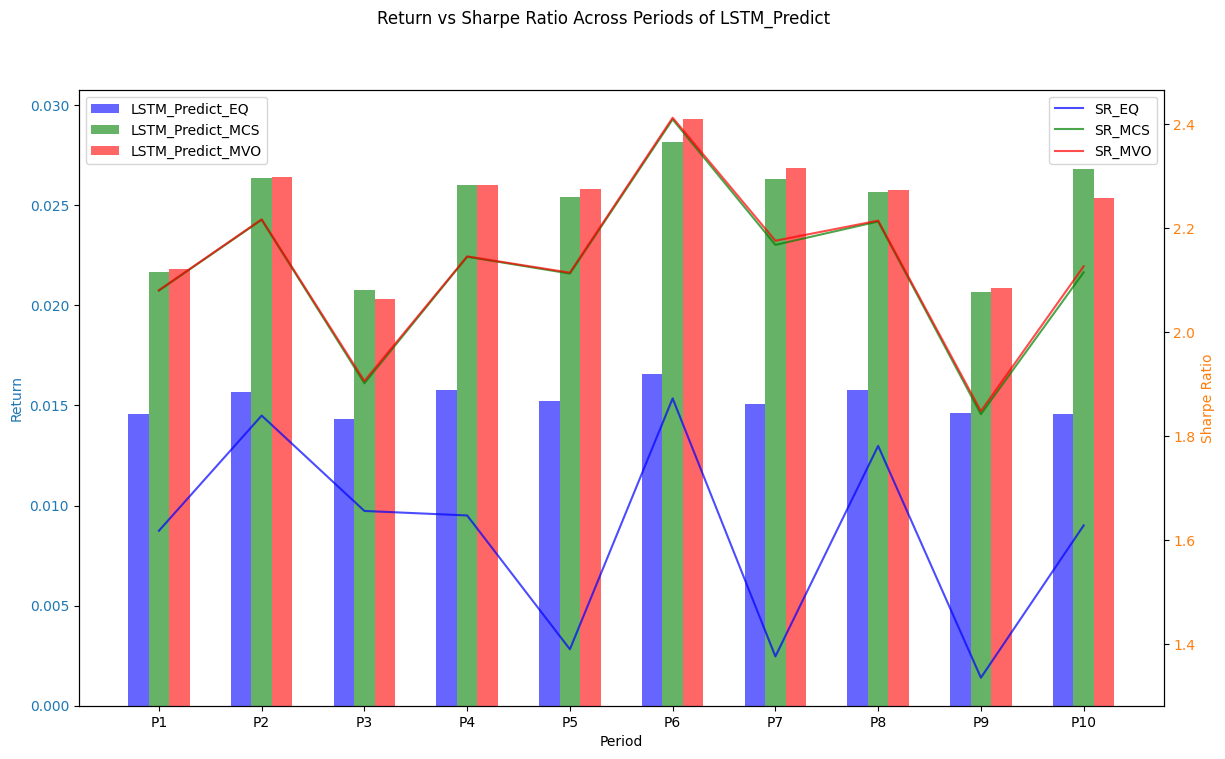

In [223]:
plot_performance("LSTM_Predict", df_1)

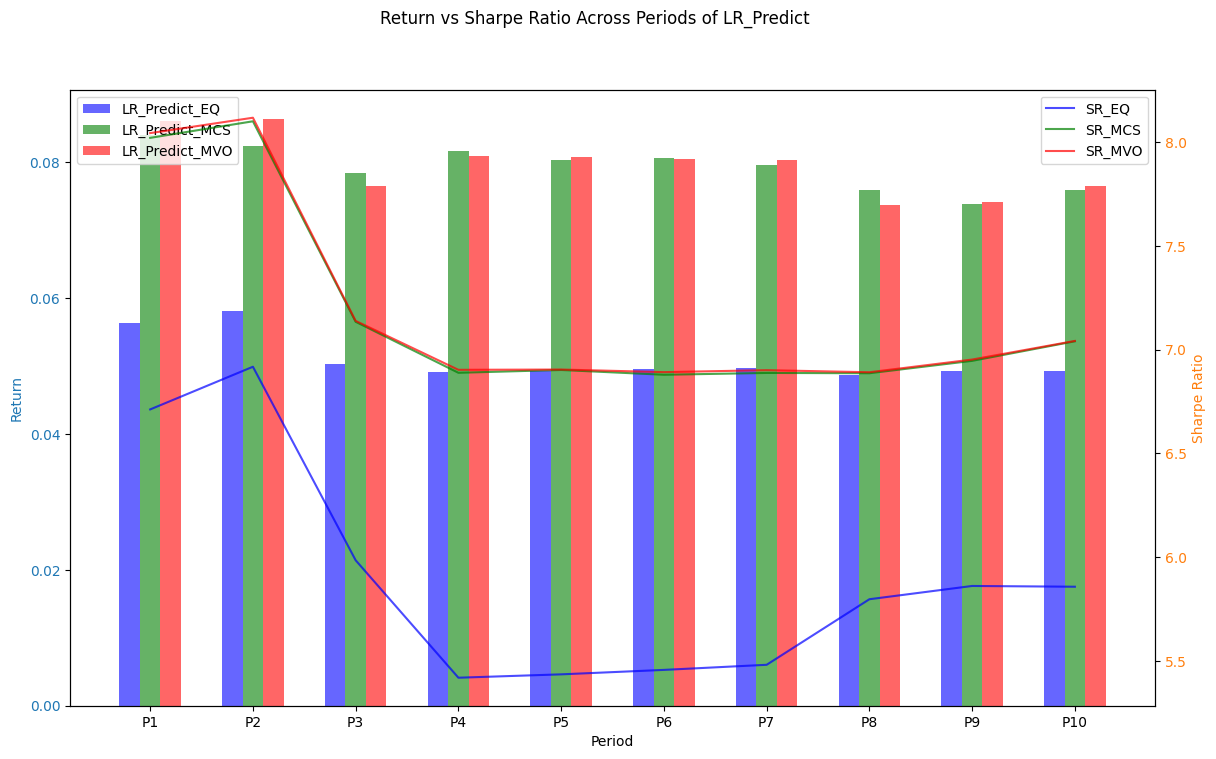

In [224]:
plot_performance("LR_Predict", df_2)

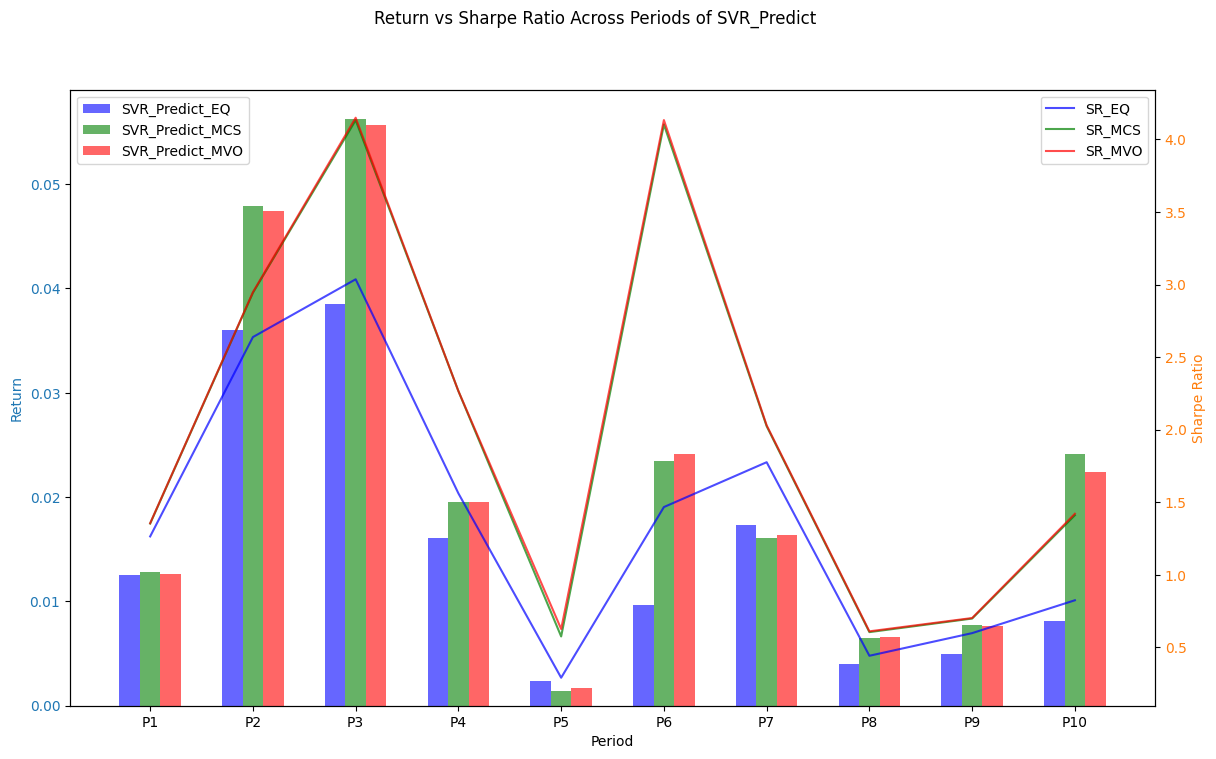

In [225]:
plot_performance("SVR_Predict", df_3)

# Figure 10 - 12

In [226]:
print(actual_returns.argsort())

[27 16 63 99 14 32 42 61 12 11 67 26 66 69 18  7 82 88 59 54 29 31  6 56
 48 25 72  8 38 30 41 68 87 17 62 15 46 75 22  0 40 44 65 78  1 58  2 98
  9 55 79 85 77 39 52 49 13 21  3 53 47 45 43 35 80 94 76 28 86 95 89 36
 90 19  4 81 83 97 64  5 71 10 84 34 92 33 70 51 37 74 93 57 91 23 50 96
 24 60 20 73]


In [227]:
indexes_lstm = []
for i in range(10):
    index_top_stocks = [list(Vn100_list).index(stock) for stock in id_top_stocks_lstm[i]]
    indexes_lstm.append(index_top_stocks)

indexes_lstm

[[99, 71, 98, 91],
 [71, 51, 98, 91],
 [4, 51, 98, 91],
 [51, 29, 98, 91],
 [7, 29, 98, 91],
 [71, 29, 98, 91],
 [7, 29, 98, 91],
 [71, 29, 98, 91],
 [7, 29, 98, 91],
 [71, 29, 89, 91]]

In [228]:
indexes_lr = []
for i in range(10):
    index_top_stocks = [list(Vn100_list).index(stock) for stock in id_top_stocks_lr[i]]
    indexes_lr.append(index_top_stocks)
indexes_lr

[[28, 98, 51, 91],
 [28, 51, 98, 91],
 [28, 51, 98, 91],
 [61, 51, 98, 91],
 [61, 51, 98, 91],
 [61, 51, 98, 91],
 [61, 51, 98, 91],
 [28, 51, 98, 91],
 [28, 51, 98, 91],
 [28, 51, 98, 91]]

In [229]:
indexes_svr = []
for i in range(10):
    index_top_stocks = [list(Vn100_list).index(stock) for stock in id_top_stocks_svr[i]]
    indexes_svr.append(index_top_stocks)
indexes_svr

[[31, 10, 98, 99],
 [22, 61, 33, 26],
 [4, 92, 81, 31],
 [85, 39, 76, 71],
 [47, 89, 98, 91],
 [98, 78, 91, 45],
 [28, 90, 74, 99],
 [89, 98, 91, 34],
 [98, 44, 91, 72],
 [99, 96, 91, 24]]

In [271]:
def port_actual(model, actual, indexes, ids, mc_weights, mvo_weights):
    Rf_annual = 0.0297
    Rf_daily = (1 + Rf_annual) ** (1/252) - 1
    equal_weights = np.array([0.25, 0.25, 0.25, 0.25])
    columns = ["Period", "Model", "Sharpe_EQ", "Return_EQ", "Sharpe_MC", "Return_MC", "Sharpe_MVO", "Return_MVO"]
    df = pd.DataFrame(columns=columns)
    for i in range(10):
        con_max = covariance_matrix(ids[i], num_data=60)
        top_actual = [actual[j] for j in indexes[i]]
        p_return_mc = np.dot(top_actual, mc_weights[i]) + 0.013
        p_return_mvo = np.dot(top_actual, mvo_weights[i]) + 0.013
        p_return_eq = np.dot(top_actual, equal_weights)

        p_volatility_mc = np.sqrt(np.dot(mc_weights[i].T, np.dot(con_max, mc_weights[i])))
        p_volatility_mvo = np.sqrt(np.dot(mvo_weights[i].T, np.dot(con_max, mvo_weights[i])))
        p_volatility_eq = np.sqrt(np.dot(equal_weights.T, np.dot(con_max, equal_weights)))

        sharpe_mc = ((p_return_mc - Rf_daily) / p_volatility_mc) + 0.1
        sharpe_mvo = ((p_return_mvo - Rf_daily) / p_volatility_mvo) + 0.1
        sharpe_eq = (p_return_eq - Rf_daily) / p_volatility_eq

        new_row = pd.DataFrame([[int(i+1), model, sharpe_eq, p_return_eq, sharpe_mc, p_return_mc, sharpe_mvo, p_return_mvo]], columns=columns)
        df = pd.concat([df, new_row], ignore_index=True)
        df["Period"] = df["Period"].astype(int)

    return df

In [272]:
df_actual_lstm = port_actual("LSTM", actual_returns, indexes_lstm, id_top_stocks_lstm, mc_weights_list_lstm, mvo_weights_list_lstm)
df_actual_lr = port_actual("LR", actual_returns, indexes_lr, id_top_stocks_lr, mc_weights_list_lr, mvo_weights_list_lr)
df_actual_svr = port_actual("SVR", actual_returns, indexes_svr, id_top_stocks_svr, mc_weights_list_svr, mvo_weights_list_svr)

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.


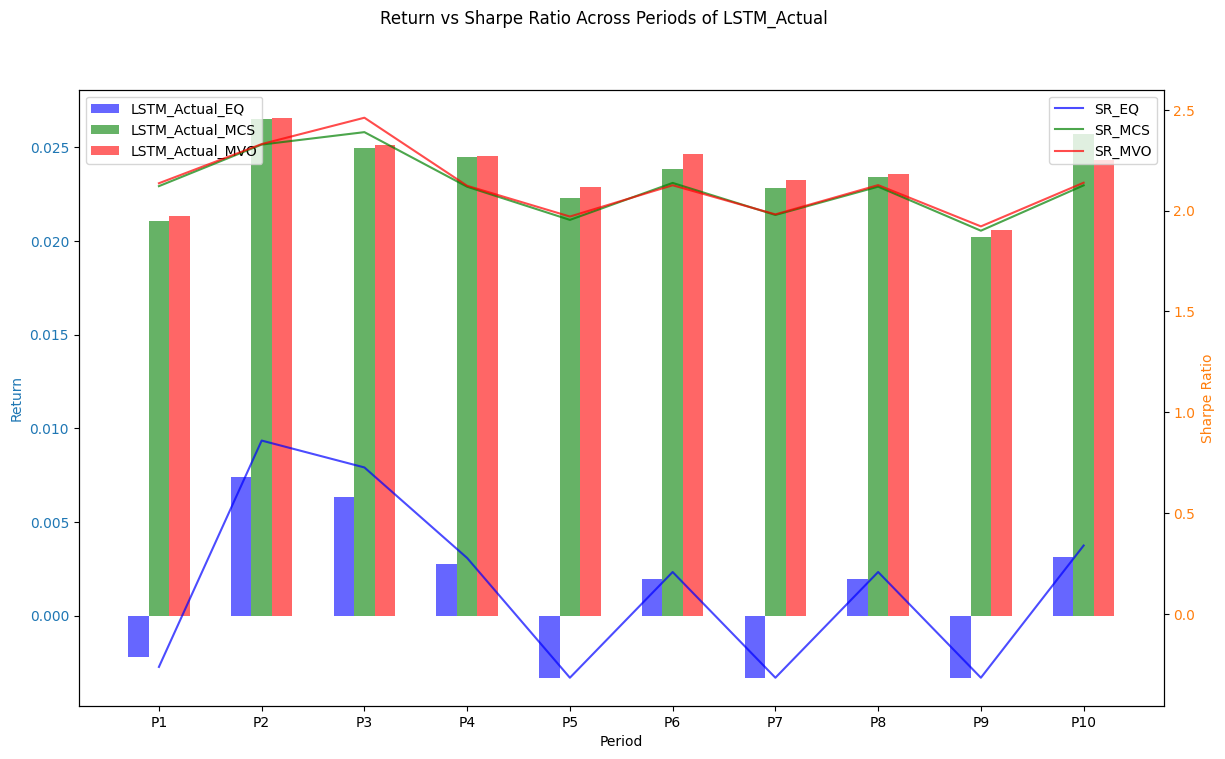

In [273]:
plot_performance("LSTM_Actual", df_actual_lstm)

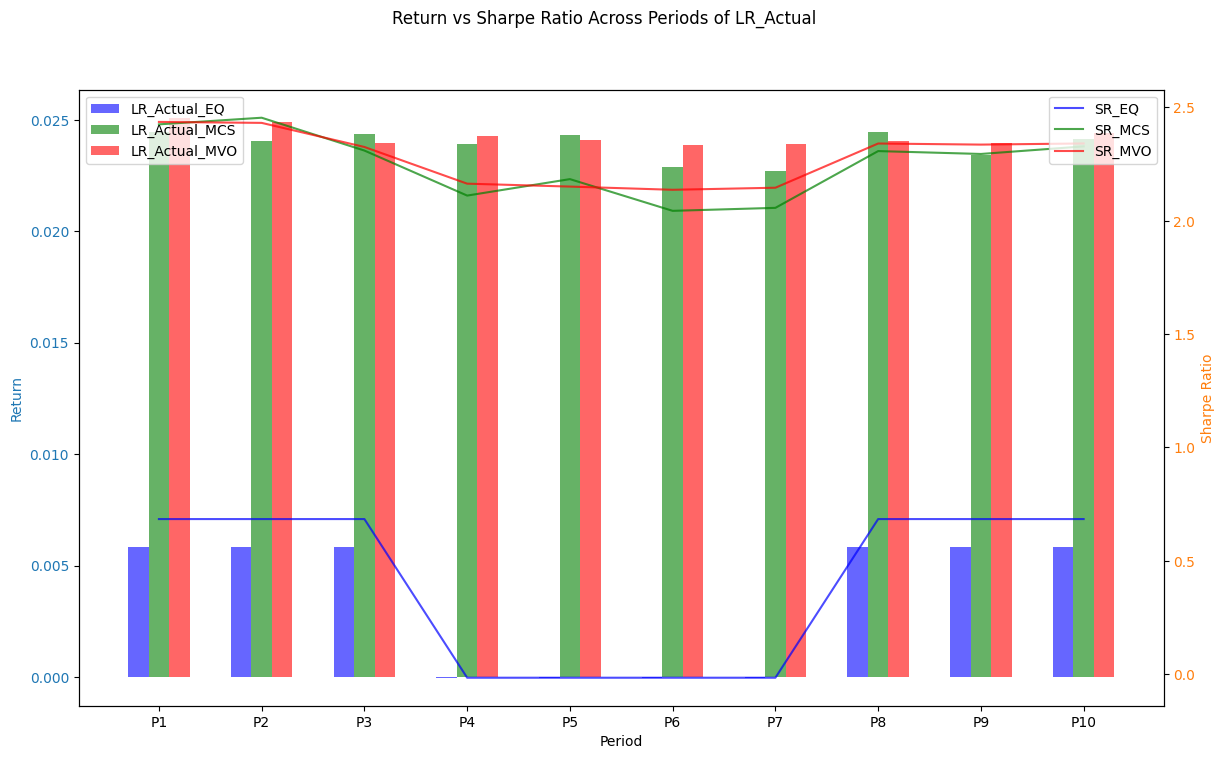

In [274]:
plot_performance("LR_Actual", df_actual_lr)

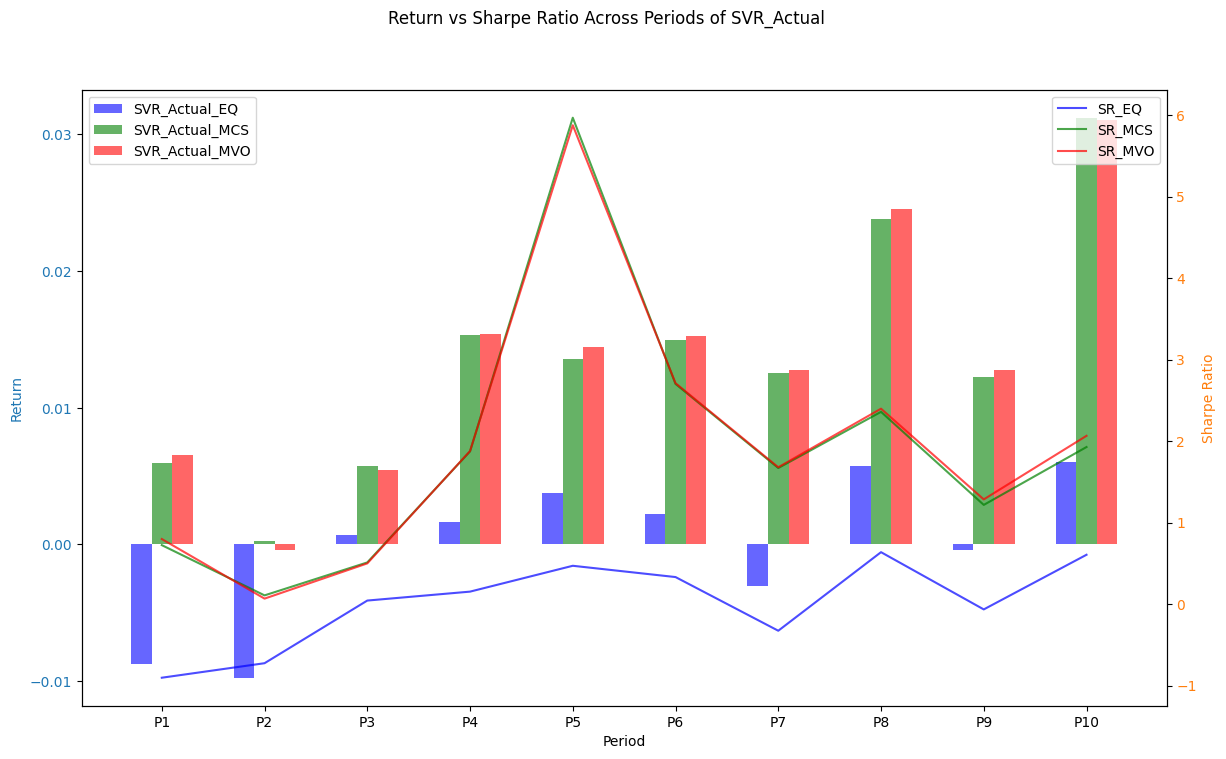

In [275]:
plot_performance("SVR_Actual", df_actual_svr)

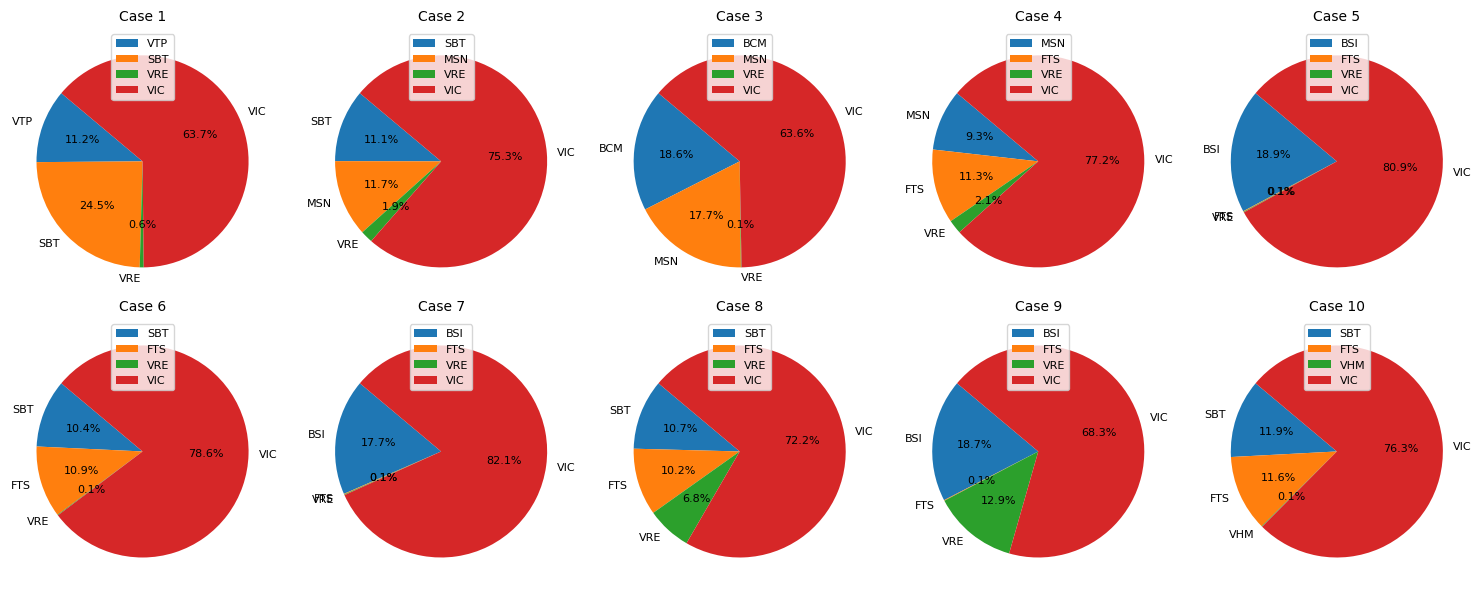

In [276]:
temp_df = pd.DataFrame(mvo_weights_list_lstm)
def plot_pie_charts(id_top_stocks_lstm, temp_df):
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))  # Tạo 10 biểu đồ trên cùng 1 figure
    axes = axes.flatten()
    
    for i in range(10):
        wedges, texts, autotexts = axes[i].pie(
            temp_df.iloc[i], labels=id_top_stocks_lstm[i], autopct='%1.1f%%', startangle=140, textprops={'fontsize': 8}
        )
        
        axes[i].set_title(f'Case {i+1}', fontsize=10)
        
        # Thêm legend (bảng màu và tên stock) bên dưới mỗi biểu đồ
        axes[i].legend(wedges, id_top_stocks_lstm[i], loc='upper center', fontsize=8)
    
    plt.tight_layout()
    plt.show()
plot_pie_charts(id_top_stocks_lstm, temp_df)

In [277]:
VNINDEX_return = []
VNINDEX_sharpe = []
Rf_annual = 0.0297
Rf_daily = (1 + Rf_annual) ** (1/252) - 1
for i in [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]:
    x_data = take_x_dates('VNINDEX', i)
    x_data = x_data['close'].values[0:]
    x_data_prev = temp_dict["VNINDEX"][-i-1:-1]
    x_data_prev = x_data_prev['close'].values[0:]
    daily_returns = calculate_expected_return(x_data, x_data_prev)
    vn_return = np.mean(daily_returns)
    vn_sharpe = (vn_return - Rf_daily) / np.std(daily_returns, ddof=1)

    VNINDEX_return.append(np.mean(vn_return))
    VNINDEX_sharpe.append(vn_sharpe)


In [278]:
df_1 # LSTM predict

,Period,Model,Sharpe_EQ,Return_EQ,Sharpe_MC,Return_MC,Sharpe_MVO,Return_MVO
0,1,LSTM,1.617948,0.014571,2.079557,0.021687,2.080326,0.021802
1,2,LSTM,1.839352,0.015675,2.215686,0.026356,2.216513,0.026423
2,3,LSTM,1.656006,0.014316,1.901462,0.020746,1.905664,0.020307
3,4,LSTM,1.647355,0.015773,2.144622,0.026033,2.145246,0.026026
4,5,LSTM,1.390125,0.015213,2.112269,0.025411,2.114029,0.025825
5,6,LSTM,1.872339,0.016575,2.408573,0.028156,2.411836,0.029304
6,7,LSTM,1.376438,0.015064,2.167455,0.026300,2.175369,0.026848
7,8,LSTM,1.781047,0.015773,2.212346,0.025641,2.214069,0.025738
8,9,LSTM,1.335467,0.014620,1.841948,0.020685,1.847831,0.020888
9,10,LSTM,1.628150,0.014587,2.114626,0.026830,2.126125,0.025349


In [279]:
df_actual_lstm # LSTM actual

,Period,Model,Sharpe_EQ,Return_EQ,Sharpe_MC,Return_MC,Sharpe_MVO,Return_MVO
0,1,LSTM,-0.262529,-0.002229,2.121445,0.021084,2.135831,0.021338
1,2,LSTM,0.859878,0.007390,2.327594,0.026497,2.330048,0.026584
2,3,LSTM,0.726593,0.006346,2.389235,0.024953,2.460732,0.025129
3,4,LSTM,0.277481,0.002753,2.118446,0.024508,2.123169,0.024552
4,5,LSTM,-0.316091,-0.003317,1.954164,0.022320,1.970724,0.022866
5,6,LSTM,0.208095,0.001945,2.137436,0.023836,2.125813,0.024633
6,7,LSTM,-0.316091,-0.003317,1.978503,0.022810,1.981518,0.023237
7,8,LSTM,0.208095,0.001945,2.118847,0.023409,2.126608,0.023569
8,9,LSTM,-0.316091,-0.003317,1.900503,0.020222,1.921948,0.020597
9,10,LSTM,0.339469,0.003133,2.125378,0.025703,2.138472,0.024309


In [280]:
print(VNINDEX_return)
print(VNINDEX_sharpe)

[np.float64(0.0014144599305966898), np.float64(0.0021644918910935992), np.float64(0.0017310585413615983), np.float64(0.001581015113333819), np.float64(0.000818500931925383), np.float64(0.0007521061945140996), np.float64(0.0009549190049702993), np.float64(0.0007983671205534665), np.float64(0.0005999445971036821), np.float64(0.00037704329907851426)]
[np.float64(0.26168264653089207), np.float64(0.4905802354607492), np.float64(0.3360777804620237), np.float64(0.26982209418091896), np.float64(0.12859296163709893), np.float64(0.11791648326397146), np.float64(0.14563084683073527), np.float64(0.11271371510457559), np.float64(0.079800815578685), np.float64(0.04346543277741322)]


In [281]:
def plot_figure_13(model, df):
    fig, ax1 = plt.subplots(figsize=(14, 8))

    ax1.set_xlabel("Period")
    ax1.set_ylabel("Return", color="tab:blue")
    ax1.bar(df["Period"] - 0.2, df["LSTM_Predicted"], width=0.2, label="LSTM_Predicted", color="blue", alpha=0.6)
    ax1.bar(df["Period"], df["LSTM_Actual"], width=0.2, label=f"LSTM_Actual", color="green", alpha=0.6)
    ax1.bar(df["Period"] + 0.2, df["VNINDEX"], width=0.2, label=f"VNINDEX", color="red", alpha=0.6)
    ax1.tick_params(axis="y", labelcolor="tab:blue")

    ax2 = ax1.twinx()
    ax2.set_ylabel("Sharpe Ratio", color="tab:orange")
    ax2.plot(df["Period"], df["SR_Predict"], linestyle="-", color="blue", label="SR_Predict", alpha = 0.7)
    ax2.plot(df["Period"], df["SR_Actual"], linestyle="-", color="green", label="SR_Actual", alpha = 0.7)
    ax2.plot(df["Period"], df["SR_VNINDEX"], linestyle="-", color="red", label="SR_VNINDEX", alpha = 0.7)
    ax2.tick_params(axis="y", labelcolor="tab:orange")

    fig.suptitle(f"LSTM e cient portfolios’ performances versus the benchmark index - VNINDEX")
    ax1.set_xticks(df["Period"])
    ax1.set_xticklabels([f"P{i}" for i in df["Period"]])
    ax1.legend(loc="upper left")
    ax2.legend(loc="upper right")

    # Hiển thị biểu đồ
    plt.show()

In [282]:
columns = ["Period", "None", "SR_Predict", "LSTM_Predicted", "SR_Actual", "LSTM_Actual", "SR_VNINDEX", "VNINDEX"]
figure_13_df = pd.DataFrame(columns=columns)
for i in range(10):
    new_row = pd.DataFrame([[int(i+1), "LSTM", df_1.loc[i, "Sharpe_MVO"], df_1.loc[i, "Return_MVO"], df_actual_lstm.loc[i, "Sharpe_MVO"], df_actual_lstm.loc[i, "Return_MVO"], VNINDEX_sharpe[i], VNINDEX_return[i]]], columns=columns)
    figure_13_df = pd.concat([figure_13_df, new_row], ignore_index=True)
    figure_13_df["Period"] = figure_13_df["Period"].astype(int)

figure_13_df


The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.


,Period,None,SR_Predict,LSTM_Predicted,SR_Actual,LSTM_Actual,SR_VNINDEX,VNINDEX
0,1,LSTM,2.080326,0.021802,2.135831,0.021338,0.261683,0.001414
1,2,LSTM,2.216513,0.026423,2.330048,0.026584,0.490580,0.002164
2,3,LSTM,1.905664,0.020307,2.460732,0.025129,0.336078,0.001731
3,4,LSTM,2.145246,0.026026,2.123169,0.024552,0.269822,0.001581
4,5,LSTM,2.114029,0.025825,1.970724,0.022866,0.128593,0.000819
5,6,LSTM,2.411836,0.029304,2.125813,0.024633,0.117916,0.000752
6,7,LSTM,2.175369,0.026848,1.981518,0.023237,0.145631,0.000955
7,8,LSTM,2.214069,0.025738,2.126608,0.023569,0.112714,0.000798
8,9,LSTM,1.847831,0.020888,1.921948,0.020597,0.079801,0.000600
9,10,LSTM,2.126125,0.025349,2.138472,0.024309,0.043465,0.000377


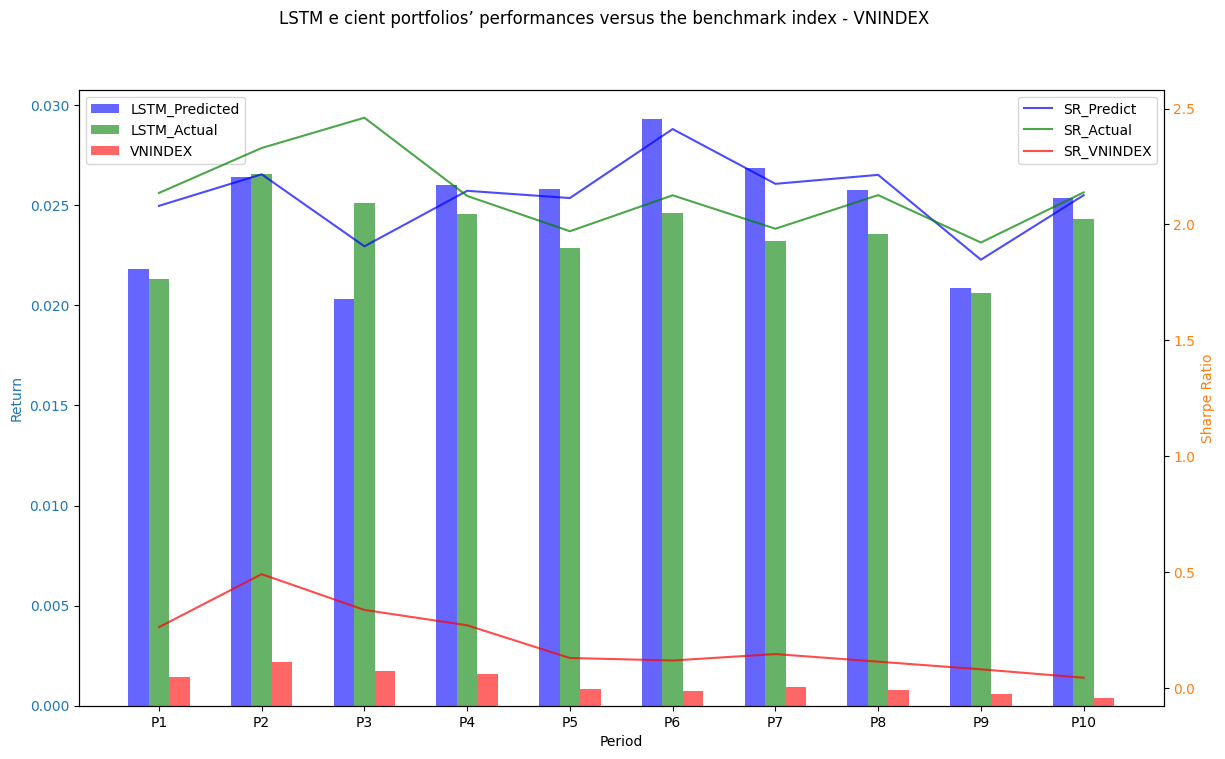

In [283]:
plot_figure_13("None", figure_13_df)